<a href="https://colab.research.google.com/github/Henry-Gbriel/Curso-USP-An-lise-de-Dados---Esalq/blob/main/Aula_Cluster_Agrupamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
pip install scikit-learn

In [101]:
pip install scipy


In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn.cluster import AgglomerativeClustering, KMeans   # Algoritmos de clustering (hierárquico e não hierárquico)
import scipy.cluster.hierarchy as sch  # Funções para clusterização hierárquica e geração de dendrogramas


Método Hierárquicos

     estudante  matemática  física  química
0     Gabriela         3.7     2.7      9.1
1  Luiz Felipe         7.8     8.0      1.5
2     Patrícia         8.9     1.0      2.7
3       Ovídio         7.0     1.0      9.0
4       Leonor         3.4     2.0      5.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   estudante   5 non-null      object 
 1   matemática  5 non-null      float64
 2   física      5 non-null      float64
 3   química     5 non-null      float64
dtypes: float64(3), object(1)
memory usage: 292.0+ bytes
None

    matemática  física  química
0         3.7     2.7      9.1
1         7.8     8.0      1.5
2         8.9     1.0      2.7
3         7.0     1.0      9.0
4         3.4     2.0      5.0


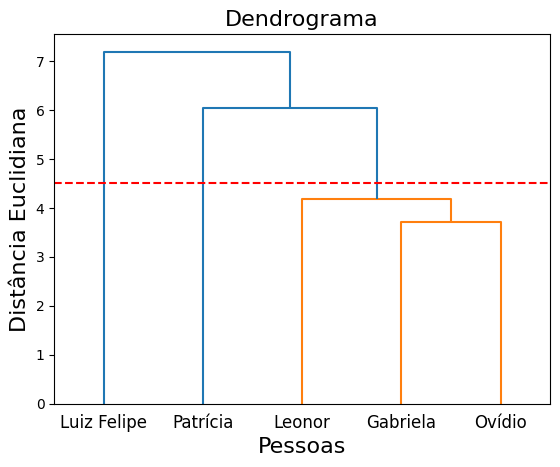

In [103]:
vestibular = pd.read_excel('/content/Vestibular.xlsx')

print(vestibular)
print(vestibular.info())


# somente as variaveis metricas
vest = vestibular.drop(columns=['estudante'])

print("\n", vest)

#No momento não é necessario aplicar o Zscore
'''
for column in vest.columns:
    vest[column] = status.zscore(vest[column])
'''

#Vamos gerar o dendrograma utilizando a metrica euclidiana

dendrogram = sch.dendrogram(sch.linkage(vest, method = 'single', metric = 'euclidean'), labels = list(vestibular.estudante))
plt.title('Dendrograma', fontsize=16)
plt.xlabel('Pessoas', fontsize=16)
plt.ylabel('Distância Euclidiana', fontsize=16)
plt.axhline(y = 4.5, color = 'red', linestyle = '--')
plt.show()

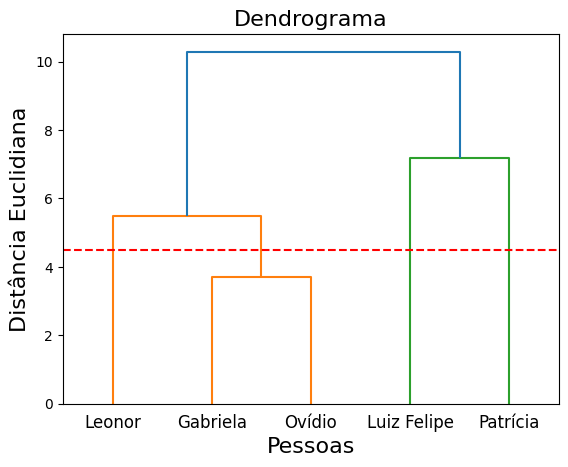

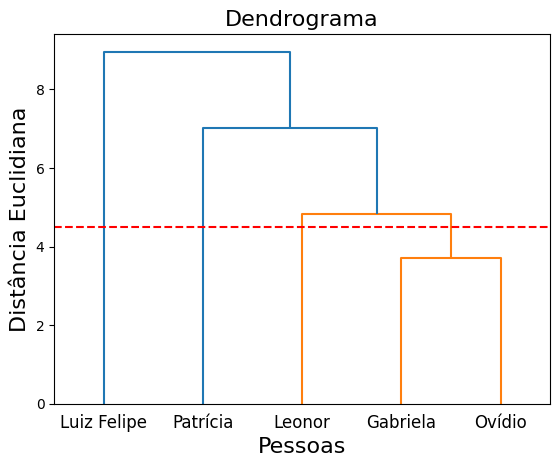

In [104]:
dendrogram = sch.dendrogram(sch.linkage(vest, method = 'complete', metric = 'euclidean'), labels = list(vestibular.estudante))
plt.title('Dendrograma', fontsize=16)
plt.xlabel('Pessoas', fontsize=16)
plt.ylabel('Distância Euclidiana', fontsize=16)
plt.axhline(y = 4.5, color = 'red', linestyle = '--')
plt.show()

print("\n")

dendrogram = sch.dendrogram(sch.linkage(vest, method = 'average', metric = 'euclidean'), labels = list(vestibular.estudante))
plt.title('Dendrograma', fontsize=16)
plt.xlabel('Pessoas', fontsize=16)
plt.ylabel('Distância Euclidiana', fontsize=16)
plt.axhline(y = 4.5, color = 'red', linestyle = '--')
plt.show()

Método Não Hierárquicos

[0 1 2 0 0]
     estudante  matemática  física  química  cluster
0     Gabriela         3.7     2.7      9.1        0
1  Luiz Felipe         7.8     8.0      1.5        1
2     Patrícia         8.9     1.0      2.7        2
3       Ovídio         7.0     1.0      9.0        0
4       Leonor         3.4     2.0      5.0        0

 Index(['matemática', 'física', 'química'], dtype='object')

          matemática  física  química
cluster                             
0               4.7     1.9      7.7
1               7.8     8.0      1.5
2               8.9     1.0      2.7


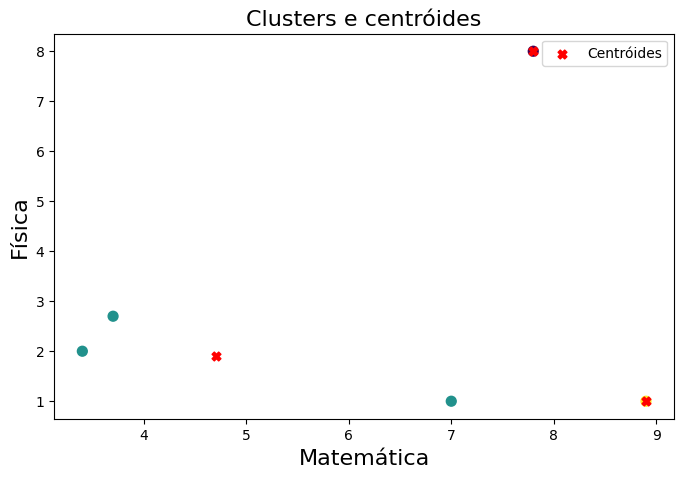

In [105]:
#No desenvolvimento da análise hierárquica encontramos três possiveis clusters
k_means = KMeans(n_clusters = 3, init = 'random').fit(vest)

kmeans_cluster = k_means.labels_

print(kmeans_cluster) # formação do clusters impressas

vestibular['cluster'] = kmeans_cluster

print(vestibular) # demonstra qual nó cada pertence


#Indentificar as centroides nos devidos nó
centroides = pd.DataFrame(k_means.cluster_centers_)
centroides.columns = vest.columns

print("\n", centroides.columns)
centroides.index.name = 'cluster'
print("\n", centroides)

#Obserações plotadas
plt.figure(figsize=(8,5))

pred_y = k_means.fit_predict(vest)

plt.scatter(vest['matemática'], vest['física'], c=pred_y, s=50, cmap='viridis')
plt.scatter(centroides['matemática'], centroides['física'], s = 40, c = 'red', label = 'Centróides', marker="X")
plt.title('Clusters e centróides', fontsize=16)
plt.xlabel('Matemática', fontsize=16)
plt.ylabel('Física', fontsize=16)
plt.legend()
plt.show()



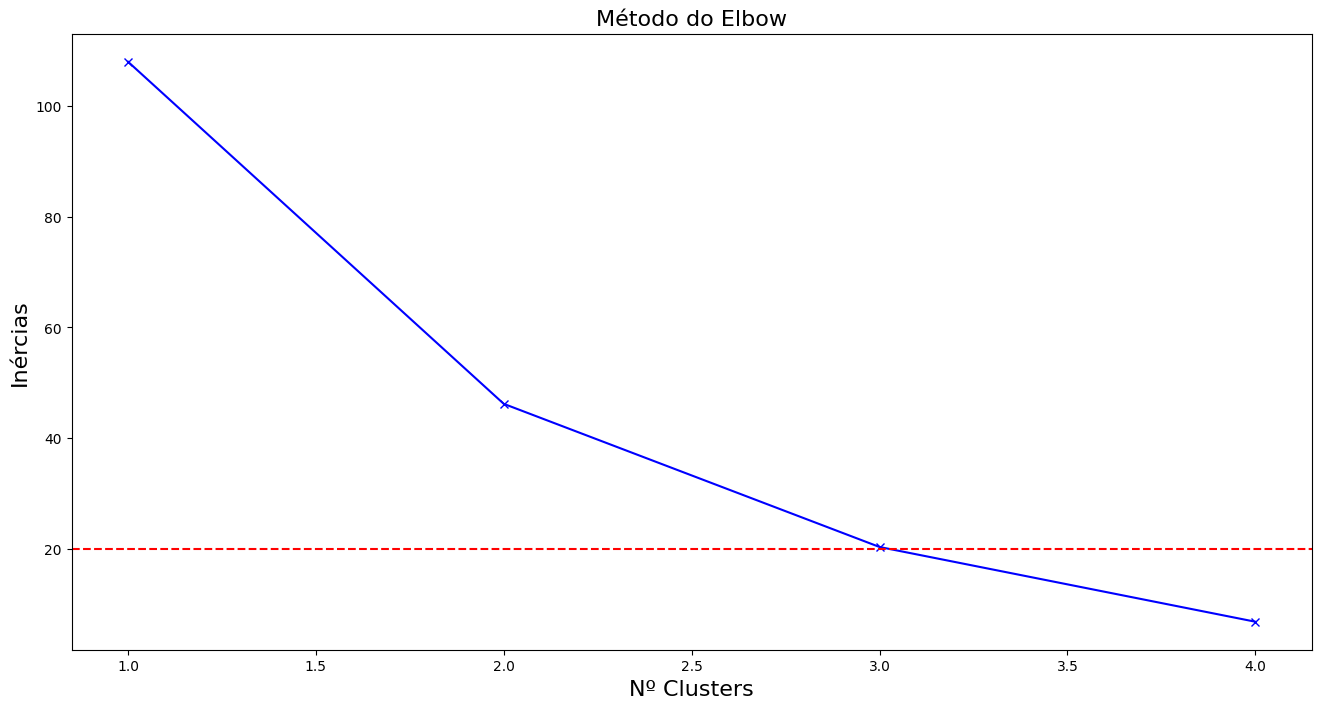

In [106]:
'''
Podemos utilizar tambem o método Elbow para identificar os números de clusters possiveis para formação

Utilizando assim: Quanto mais próximos entre si e do centróide, menor a inércia
'''
inercias = []
K = range(1,vest.shape[0])
for k in K:
    kmeanModel = KMeans(n_clusters=k).fit(vest)
    inercias.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K, inercias, 'bx-')
plt.axhline(y = 20, color = 'red', linestyle = '--')
plt.xlabel('Nº Clusters', fontsize=16)
plt.ylabel('Inércias', fontsize=16)
plt.title('Método do Elbow', fontsize=16)
plt.show()

In [107]:
# As variáveis que mais contribuem para formação de pelo menos um cluster
'''
Se os dados são tambem estatisitcamente relevantes para formção
'''

def teste_f_kmeans(kmeans, dataframe):

    variaveis = dataframe.columns

    centroides = pd.DataFrame(kmeans.cluster_centers_)
    centroides.columns = dataframe.columns
    centroides

    print("Centróides: \n", centroides ,"\n")

    df = dataframe[variaveis]

    unique, counts = np.unique(kmeans.labels_, return_counts=True)

    dic = dict(zip(unique, counts))

    qnt_clusters = kmeans.n_clusters

    observacoes = len(kmeans.labels_)

    df['cluster'] = kmeans.labels_

    output = []

    for variavel in variaveis:

        dic_var={'variavel':variavel}

        # variabilidade entre os grupos

        variabilidade_entre_grupos = np.sum([dic[index]*np.square(observacao - df[variavel].mean()) for index, observacao in enumerate(centroides[variavel])])/(qnt_clusters - 1)

        dic_var['variabilidade_entre_grupos'] = variabilidade_entre_grupos

        variabilidade_dentro_dos_grupos = 0

        for grupo in unique:

            grupo = df[df.cluster == grupo]

            variabilidade_dentro_dos_grupos += np.sum([np.square(observacao - grupo[variavel].mean()) for observacao in grupo[variavel]])/(observacoes - qnt_clusters)

        dic_var['variabilidade_dentro_dos_grupos'] = variabilidade_dentro_dos_grupos

        dic_var['F'] =  dic_var['variabilidade_entre_grupos']/dic_var['variabilidade_dentro_dos_grupos']

        dic_var['sig F'] =  1 - stats.f.cdf(dic_var['F'], qnt_clusters - 1, observacoes - qnt_clusters)

        output.append(dic_var)

    df = pd.DataFrame(output)

    print(df)

    return df

output = teste_f_kmeans(k_means,vest)

Centróides: 
    matemática  física  química
0         7.8     8.0      1.5
1         4.7     1.9      7.7
2         8.9     1.0      2.7 

     variavel  variabilidade_entre_grupos  variabilidade_dentro_dos_grupos  \
0  matemática                       8.296                             3.99   
1      física                      16.306                             0.73   
2     química                      19.176                             5.47   

           F     sig F  
0   2.079198  0.324760  
1  22.336986  0.042850  
2   3.505667  0.221943  


In [114]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default='colab'

fig = px.scatter_3d(vestibular,
                    x='matemática',
                    y='química',
                    z='física',
                    color='cluster')
fig.show()


Exemplo Dois

In [124]:
dados_varejista = pd.read_excel('/content/Regional Varejista (Cluster).xlsx')

print(dados_varejista)
print("\n", dados_varejista.info)

varejista = dados_varejista.drop(columns=['loja', 'regional'])

print("\n", varejista)



    loja    regional  atendimento  sortimento  organização
0      1  Regional 3            6           6            4
1      2  Regional 3           14           2            4
2      3  Regional 3            8           4            6
3      4  Regional 3            4           4            4
4      5  Regional 3            6           6            6
5      6  Regional 2           38          38          100
6      7  Regional 1           40          78           38
7      8  Regional 3            6           4            4
8      9  Regional 3            4           4            6
9     10  Regional 3            6           6            2
10    11  Regional 2           54          32           86
11    12  Regional 2           52          34           98
12    13  Regional 2           76          60           88
13    14  Regional 1           78          86           38
14    15  Regional 1           54          76           58
15    16  Regional 3            2           4           

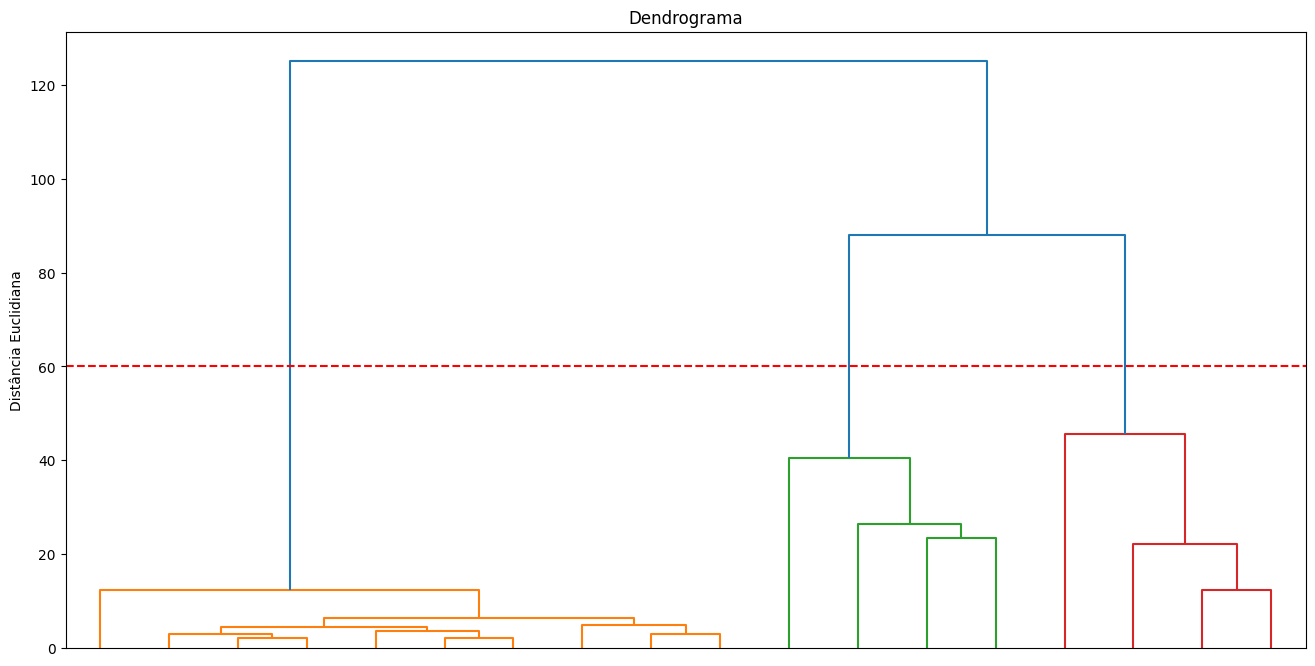

In [127]:
# Gerando o dendrograma

plt.figure(figsize=(16,8))
dendrogram = sch.dendrogram(sch.linkage(varejista, method = 'complete', metric = 'euclidean'))
plt.axhline(y = 60, color = 'red', linestyle = '--')
plt.title('Dendrograma')
plt.xticks([]) # Procedimento para retirar os pontos do eixo x quando existirem muitas observações
plt.ylabel('Distância Euclidiana')
plt.show()